Setting up the backgrounds provided by the case study

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_products = 5
days = 180
dates = pd.date_range("2025-01-01", periods=days, freq="D")

base_price = np.array([50, 60, 40, 80, 55], dtype=float)
cost = np.array([25, 30, 22, 45, 28], dtype=float)

true_elasticity = np.array([-1.6, -1.2, -0.9, -0.7, -0.5])
promo_lift = 0.30
comp_effect = 0.6
season_effect = 1.0

rows = []
for i in range(n_products):
    for t, d in enumerate(dates):
        season = 1.0 + 0.15*np.sin(2*np.pi*t/30) + rng.normal(0, 0.03)
        season = float(np.clip(season, 0.8, 1.2))

        promo = int(rng.random() < 0.18)

        comp_price = base_price[i] * (1.02 + rng.normal(0, 0.05))
        comp_price = max(comp_price, 1.0)

        p = base_price[i] * (1.0 + rng.normal(0, 0.06))
        if promo:
            p *= (1.0 - rng.uniform(0.05, 0.20))
        p = max(p, cost[i] * 1.02)

        alpha = 3.6 + rng.normal(0, 0.10)
        eps = rng.normal(0, 0.20)

        log_q = (alpha
                 + true_elasticity[i] * np.log(p)
                 + promo_lift * promo
                 + comp_effect * np.log(comp_price)
                 + season_effect * np.log(season)
                 + eps)

        q = max(int(np.round(np.exp(log_q))), 0)
        rows.append([d, i+1, p, promo, comp_price, season, q, cost[i]])

df = pd.DataFrame(rows, columns=[
    "date", "product_id", "price", "promotion", "competitor_price",
    "seasonality_index", "units_sold", "cost"
])

cutoff = df["date"].min() + pd.Timedelta(days=150)
train = df[df["date"] <= cutoff].copy()
test  = df[df["date"] >  cutoff].copy()

print("df/train/test:", df.shape, train.shape, test.shape)
df.sample(10)


df/train/test: (900, 8) (755, 8) (145, 8)


,date,product_id,price,promotion,competitor_price,seasonality_index,units_sold,cost
58,2025-02-28,1,49.624973,0,48.353660,0.950491,1,25.0
18,2025-01-19,1,50.698029,0,49.676268,0.868450,1,25.0
661,2025-05-02,4,76.072304,0,81.520969,1.020068,19,45.0
39,2025-02-09,1,55.510741,0,48.258036,1.200000,1,25.0
33,2025-02-03,1,46.020822,0,53.289756,1.061823,1,25.0
478,2025-04-29,3,41.274936,0,38.763765,0.863507,10,22.0
463,2025-04-14,3,41.224333,0,38.285235,1.152796,16,22.0
8,2025-01-09,1,43.810108,1,51.722798,1.169546,1,25.0
726,2025-01-07,5,51.533614,0,60.757857,1.144431,67,28.0
417,2025-02-27,3,37.621345,0,43.544685,0.882919,13,22.0


Constructing the demand functions with the idea of demand price elasticity

In [ ]:
FEATURES = ["log_price", "promotion", "log_comp", "log_season"]

def add_log_features(data):
    data = data.copy()
    data["units_sold"] = np.maximum(data["units_sold"], 1)  # avoid log(0)
    data["price"] = data["price"].clip(lower=1e-6)
    data["competitor_price"] = data["competitor_price"].clip(lower=1e-6)
    data["seasonality_index"] = data["seasonality_index"].clip(lower=1e-6)

    data["log_units"] = np.log(data["units_sold"])
    data["log_price"] = np.log(data["price"])
    data["log_comp"] = np.log(data["competitor_price"])
    data["log_season"] = np.log(data["seasonality_index"])
    return data

def fit_product_model(data):
    data = add_log_features(data)
    X = data[FEATURES]
    X = sm.add_constant(X, has_constant="add")
    y = data["log_units"]
    return sm.OLS(y, X).fit()

models = {}
elasticity_rows = []

for pid in sorted(train["product_id"].unique()):
    m = fit_product_model(train[train["product_id"] == pid])
    models[pid] = m
    elasticity_rows.append([pid, m.params["log_price"]])

elasticity_df = pd.DataFrame(elasticity_rows, columns=["product_id", "est_elasticity"])
elasticity_df



,product_id,est_elasticity
0,1,-0.503015
1,2,-1.502358
2,3,-0.702473
3,4,-0.041548
4,5,-0.296230


In [ ]:
def predict_units(model, data):
    df_ = data.copy()
    df_["price"] = df_["price"].clip(lower=1e-6)
    df_["competitor_price"] = df_["competitor_price"].clip(lower=1e-6)
    df_["seasonality_index"] = df_["seasonality_index"].clip(lower=1e-6)

    df_["log_price"] = np.log(df_["price"])
    df_["log_comp"] = np.log(df_["competitor_price"])
    df_["log_season"] = np.log(df_["seasonality_index"])

    X = df_[["log_price", "promotion", "log_comp", "log_season"]]
    X = sm.add_constant(X, has_constant="add")


    X = X.reindex(columns=model.model.exog_names, fill_value=0.0)
    if "const" in X.columns:
        X["const"] = 1.0

    log_pred = model.predict(X)
    return np.exp(log_pred)


Define the optimal price function for each products, listing the possible outcomes of predicted profits

In [ ]:
def optimal_price_for_product(pid, model, df_ref):
    sub = df_ref[df_ref["product_id"] == pid]
    if sub.empty:
        raise ValueError(f"No data for product_id={pid}")

    comp0 = float(sub["competitor_price"].mean())
    season0 = float(sub["seasonality_index"].mean())
    cost0 = float(sub["cost"].iloc[0])
    p0 = float(sub["price"].mean())

    grid = np.linspace(0.8*p0, 1.2*p0, 60)

    best = {"price": None, "q_hat": None, "profit": -np.inf}
    for p in grid:
        tmp = pd.DataFrame({
            "price": [p],
            "promotion": [0],
            "competitor_price": [comp0],
            "seasonality_index": [season0],
        })
        q_hat = float(predict_units(model, tmp).iloc[0])
        profit = (p - cost0) * q_hat
        if profit > best["profit"]:
            best = {"price": p, "q_hat": q_hat, "profit": profit}
    return best

opt_rows = []
for pid in sorted(train["product_id"].unique()):
    best = optimal_price_for_product(pid, models[pid], train)
    opt_rows.append([pid, best["price"], best["q_hat"], best["profit"]])

opt_df = pd.DataFrame(opt_rows, columns=["product_id", "optimal_price", "pred_units", "pred_profit"])
print(opt_df)
print("Total predicted profit:", opt_df["pred_profit"].sum())



   product_id  optimal_price  pred_units  pred_profit
0           1      57.767174    0.926419    30.356129
1           2      69.861985    2.374199    94.640280
2           3      46.905633   11.304376   281.542641
3           4      94.251858   23.251185  1145.164076
4           5      64.297570   53.217004  1931.647940
Total predicted profit: 3483.3510668920862


In [ ]:


def compute_baseline_vs_optimized(train, models, opt_df, predict_units_func):
    rows = []
    for pid in sorted(train["product_id"].unique()):
        sub = train[train["product_id"] == pid]

        # Baseline
        p0 = float(sub["price"].mean())
        cost0 = float(sub["cost"].iloc[0])
        comp0 = float(sub["competitor_price"].mean())
        season0 = float(sub["seasonality_index"].mean())

        tmp0 = pd.DataFrame({
            "price": [p0],
            "promotion": [0],
            "competitor_price": [comp0],
            "seasonality_index": [season0]
        })
        q0 = float(predict_units_func(models[pid], tmp0).iloc[0])
        rev0 = p0 * q0
        prof0 = (p0 - cost0) * q0

        # Optimized
        p_star = float(opt_df.loc[opt_df["product_id"] == pid, "optimal_price"].iloc[0])
        tmp1 = pd.DataFrame({
            "price": [p_star],
            "promotion": [0],
            "competitor_price": [comp0],
            "seasonality_index": [season0]
        })
        q1 = float(predict_units_func(models[pid], tmp1).iloc[0])
        rev1 = p_star * q1
        prof1 = (p_star - cost0) * q1

        rows.append({
            "product_id": pid,
            "baseline_price": p0,
            "optimized_price": p_star,
            "baseline_units": q0,
            "optimized_units": q1,
            "baseline_revenue": rev0,
            "optimized_revenue": rev1,
            "baseline_profit": prof0,
            "optimized_profit": prof1,
            "profit_uplift_pct": (prof1 - prof0) / prof0 if prof0 != 0 else np.nan
        })
    return pd.DataFrame(rows)

comparison_df = compute_baseline_vs_optimized(train, models, opt_df, predict_units)
comparison_df


,product_id,baseline_price,optimized_price,baseline_units,optimized_units,baseline_revenue,optimized_revenue,baseline_profit,optimized_profit,profit_uplift_pct
0,1,48.139311,57.767174,1.015399,0.926419,48.880611,53.516602,23.495635,30.356129,0.291990
1,2,58.218321,69.861985,3.122307,2.374199,181.775496,165.866246,88.106274,94.640280,0.074161
2,3,39.088027,46.905633,12.849000,11.304376,502.242054,530.238919,219.564057,281.542641,0.282280
3,4,78.543215,94.251858,23.427982,23.251185,1840.109027,2191.467422,785.849833,1145.164076,0.457230
4,5,53.581309,64.297570,56.170240,53.217004,3009.674963,3421.724043,1436.908247,1931.647940,0.344308


Building up histograms of profit comparison between baseline and optimized pricing strategy

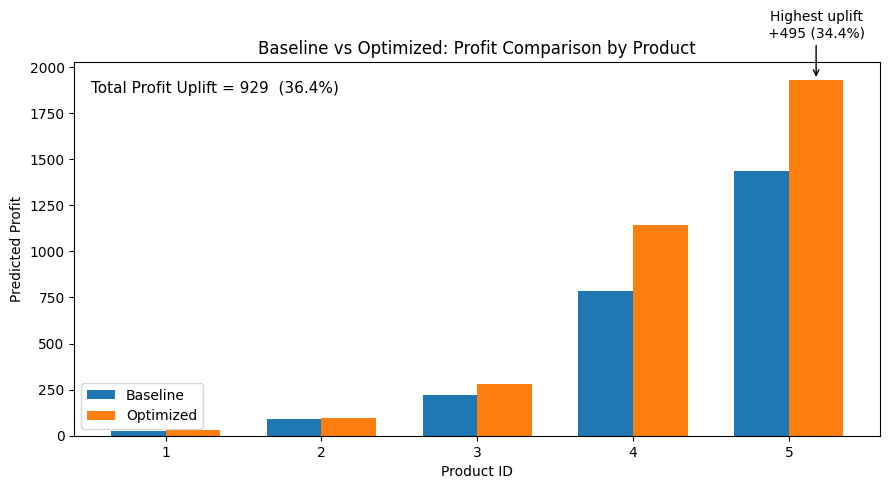

In [ ]:

x = comparison_df["product_id"].astype(str).to_numpy()
idx = np.arange(len(x))
w = 0.35


baseline = comparison_df["baseline_profit"].to_numpy()
optimized = comparison_df["optimized_profit"].to_numpy()

gap = optimized - baseline
uplift_pct = np.where(baseline != 0, gap / baseline * 100, np.nan)

total_baseline = baseline.sum()
total_optimized = optimized.sum()
total_uplift = total_optimized - total_baseline
total_uplift_pct = (total_uplift / total_baseline * 100) if total_baseline != 0 else np.nan


i_max_gap = int(np.nanargmax(gap))
i_max_opt = int(np.nanargmax(optimized))

plt.figure(figsize=(9, 5))


plt.bar(idx - w/2, baseline,  width=w, label="Baseline")
plt.bar(idx + w/2, optimized, width=w, label="Optimized")

plt.xticks(idx, x)
plt.xlabel("Product ID")
plt.ylabel("Predicted Profit")
plt.title("Baseline vs Optimized: Profit Comparison by Product")
plt.legend()


plt.text(
    0.02, 0.95,
    f"Total Profit Uplift = {total_uplift:,.0f}  ({total_uplift_pct:.1f}%)",
    transform=plt.gca().transAxes,
    fontsize=11,
    va="top"
)


y1 = max(baseline[i_max_gap], optimized[i_max_gap])
plt.annotate(
    f"Highest uplift\n+{gap[i_max_gap]:,.0f} ({uplift_pct[i_max_gap]:.1f}%)",
    xy=(idx[i_max_gap] + w/2, optimized[i_max_gap]),
    xytext=(idx[i_max_gap] + w/2, y1 * 1.12),
    arrowprops=dict(arrowstyle="->"),
    ha="center",
    fontsize=10
)


# y2 = optimized[i_max_opt]
# plt.annotate(
#     "Highest profit\n(Optimized)",
#     xy=(idx[i_max_opt] + w/2, y2),
#     xytext=(idx[i_max_opt] + w/2, y2 * 1.08),
#     arrowprops=dict(arrowstyle="->"),
#     ha="center",
#     fontsize=10
# )

plt.tight_layout()
plt.show()


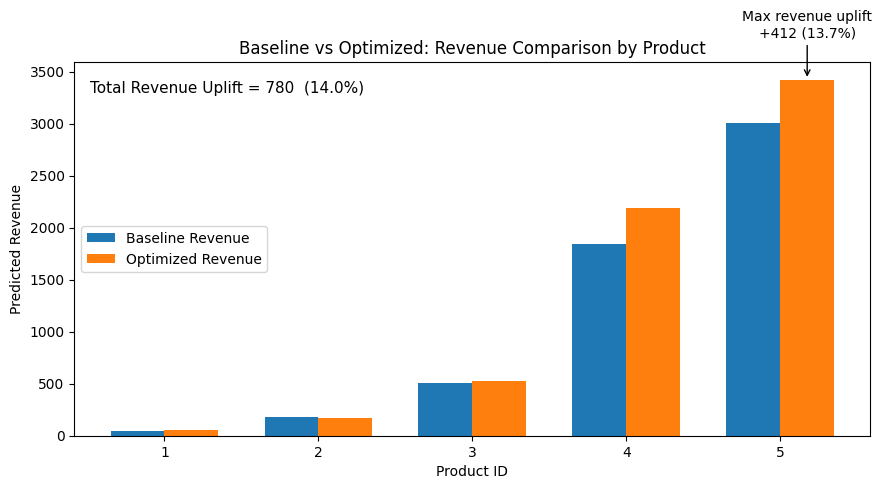

In [ ]:



x = comparison_df["product_id"].astype(str).to_numpy()
idx = np.arange(len(x))
w = 0.35

baseline = comparison_df["baseline_revenue"].to_numpy()
optimized = comparison_df["optimized_revenue"].to_numpy()


gap = optimized - baseline
uplift_pct = np.where(baseline != 0, gap / baseline * 100, np.nan)

total_baseline = baseline.sum()
total_optimized = optimized.sum()
total_uplift = total_optimized - total_baseline
total_uplift_pct = (total_uplift / total_baseline * 100) if total_baseline != 0 else np.nan


i_max_gap = int(np.nanargmax(gap))

plt.figure(figsize=(9, 5))

plt.bar(idx - w/2, baseline,  width=w, label="Baseline Revenue")
plt.bar(idx + w/2, optimized, width=w, label="Optimized Revenue")

plt.xticks(idx, x)
plt.xlabel("Product ID")
plt.ylabel("Predicted Revenue")


plt.title("Baseline vs Optimized: Revenue Comparison by Product")

plt.legend()

plt.text(
    0.02, 0.95,
    f"Total Revenue Uplift = {total_uplift:,.0f}  ({total_uplift_pct:.1f}%)",
    transform=plt.gca().transAxes,
    fontsize=11,
    va="top"
)


y_top = max(baseline[i_max_gap], optimized[i_max_gap])
plt.annotate(
    f"Max revenue uplift\n+{gap[i_max_gap]:,.0f} ({uplift_pct[i_max_gap]:.1f}%)",
    xy=(idx[i_max_gap] + w/2, optimized[i_max_gap]),
    xytext=(idx[i_max_gap] + w/2, y_top * 1.12),
    arrowprops=dict(arrowstyle="->"),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()



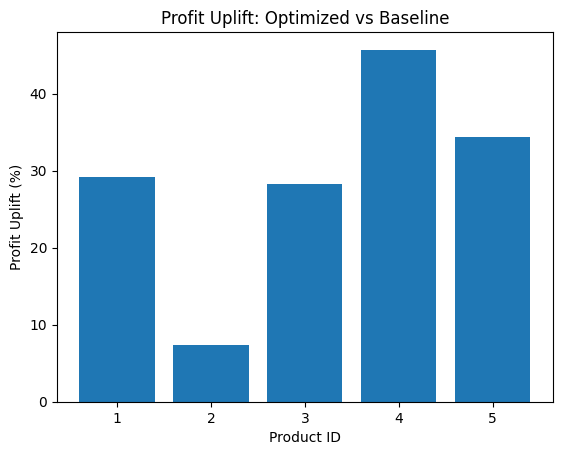

In [ ]:
plt.figure()
plt.bar(comparison_df["product_id"].astype(str), comparison_df["profit_uplift_pct"] * 100)
plt.xlabel("Product ID")
plt.ylabel("Profit Uplift (%)")
plt.title("Profit Uplift: Optimized vs Baseline")
plt.show()


In [ ]:
def cost_plus_price(cost, markup=0.20):
    """
    Cost-plus pricing
    cost: unit cost
    markup: markup rate (e.g. 20%)
    """
    return cost * (1 + markup)


In [ ]:
def compare_pricing_strategies(pid, model, df_ref, markup=0.20):
    sub = df_ref[df_ref["product_id"] == pid]


    comp0 = float(sub["competitor_price"].mean())
    season0 = float(sub["seasonality_index"].mean())
    cost0 = float(sub["cost"].iloc[0])
    p_avg = float(sub["price"].mean())

    p_cost = cost_plus_price(cost0, markup)

    df_cost = pd.DataFrame({
        "price": [p_cost],
        "promotion": [0],
        "competitor_price": [comp0],
        "seasonality_index": [season0],
    })

    q_cost = float(predict_units(model, df_cost)[0])
    profit_cost = (p_cost - cost0) * q_cost

    grid = np.linspace(0.8 * p_avg, 1.2 * p_avg, 60)
    best = {"price": None, "units": None, "profit": -np.inf}

    for p in grid:
        tmp = pd.DataFrame({
            "price": [p],
            "promotion": [0],
            "competitor_price": [comp0],
            "seasonality_index": [season0],
        })
        q_hat = float(predict_units(model, tmp)[0])
        profit = (p - cost0) * q_hat
        if profit > best["profit"]:
            best = {"price": p, "units": q_hat, "profit": profit}

    return {
        "product_id": pid,
        "cost_plus_price": p_cost,
        "cost_plus_units": q_cost,
        "cost_plus_profit": profit_cost,
        "optimal_price": best["price"],
        "optimal_units": best["units"],
        "optimal_profit": best["profit"],
        "profit_uplift": best["profit"] - profit_cost
    }


In [ ]:
rows = []
for pid in sorted(train["product_id"].unique()):
    rows.append(compare_pricing_strategies(pid, models[pid], train, markup=0.20))

comparison_df = pd.DataFrame(rows)
print(comparison_df)


   product_id  cost_plus_price  cost_plus_units  cost_plus_profit  \
0           1             30.0         1.288087          6.440436   
1           2             36.0         6.428411         38.570468   
2           3             26.4        16.927732         74.482019   
3           4             54.0        23.795524        214.159720   
4           5             33.6        64.497727        361.187270   

   optimal_price  optimal_units  optimal_profit  profit_uplift  
0      57.767174       0.926419       30.356129      23.915693  
1      69.861985       2.374199       94.640280      56.069813  
2      46.905633      11.304376      281.542641     207.060622  
3      94.251858      23.251185     1145.164076     931.004355  
4      64.297570      53.217004     1931.647940    1570.460670  


In [ ]:
total_cost_plus_profit = comparison_df["cost_plus_profit"].sum()
total_optimal_profit = comparison_df["optimal_profit"].sum()

print("Total cost-plus profit:", total_cost_plus_profit)
print("Total optimal profit:", total_optimal_profit)
print("Total profit uplift:", total_optimal_profit - total_cost_plus_profit)


Total cost-plus profit: 694.8399129927568
Total optimal profit: 3483.3510668920862
Total profit uplift: 2788.5111538993297


Histograms of profit comparison between cost-plus and optimized pricing strategy

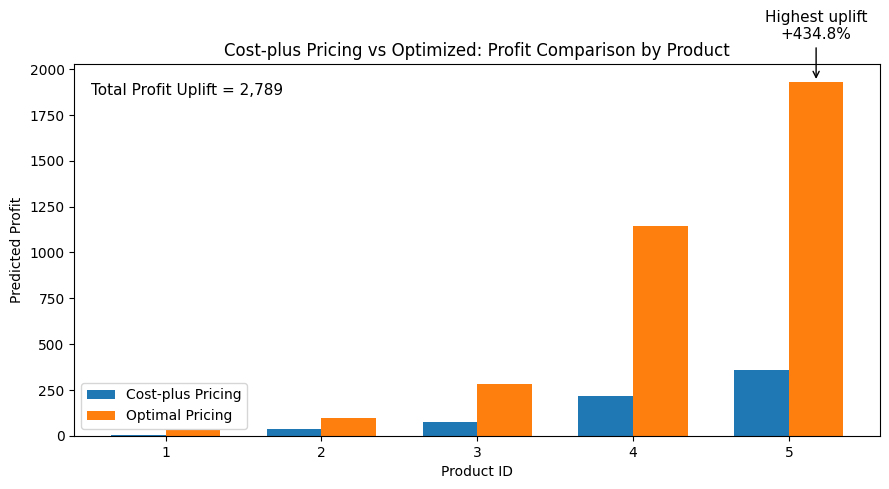

In [ ]:

plot_df = comparison_df.sort_values("product_id").copy()

plot_df["profit_gap"] = plot_df["optimal_profit"] - plot_df["cost_plus_profit"]
plot_df["uplift_pct"] = plot_df["profit_gap"] / plot_df["cost_plus_profit"] * 100

idx_max = plot_df["profit_gap"].idxmax()
max_row = plot_df.loc[idx_max]


x = np.arange(len(plot_df))
w = 0.35

plt.figure(figsize=(9, 5))


plt.bar(x - w/2, plot_df["cost_plus_profit"], width=w, label="Cost-plus Pricing")
plt.bar(x + w/2, plot_df["optimal_profit"],  width=w, label="Optimal Pricing")

plt.xticks(x, plot_df["product_id"].astype(str))
plt.xlabel("Product ID")
plt.ylabel("Predicted Profit")
plt.title("Cost-plus Pricing vs Optimized: Profit Comparison by Product")
plt.legend()

x_pos = plot_df.index.get_loc(idx_max)
y_opt = max_row["optimal_profit"]

plt.text(
    0.02, 0.95,
    f"Total Profit Uplift = {profit_uplift:,.0f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top"
)

plt.annotate(
    f"Highest uplift\n+{max_row['uplift_pct']:.1f}%",
    xy=(x_pos + w/2, y_opt),
    xytext=(x_pos + w/2, y_opt * 1.12),
    arrowprops=dict(arrowstyle="->"),
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.show()


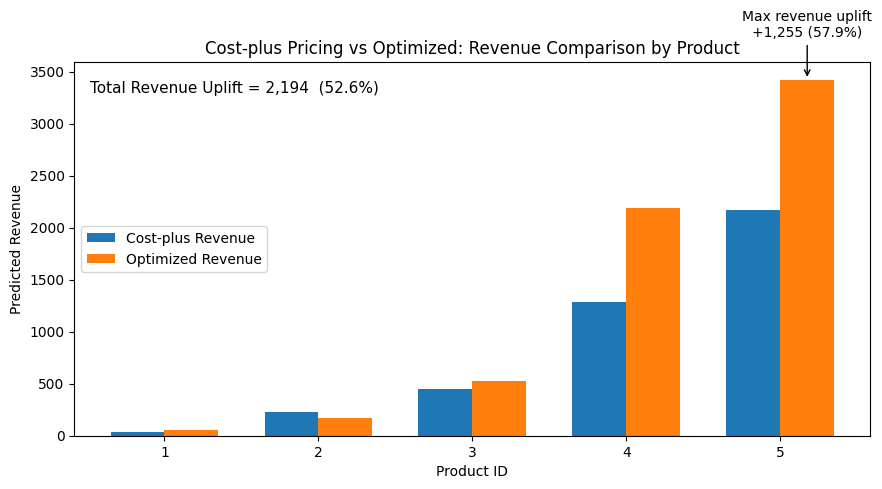

In [ ]:


comparison_df = comparison_df.copy()

comparison_df["cost_plus_revenue"] = (
    comparison_df["cost_plus_price"] * comparison_df["cost_plus_units"]
)
comparison_df["optimized_revenue"] = (
    comparison_df["optimal_price"] * comparison_df["optimal_units"]
)


x = comparison_df["product_id"].astype(str).to_numpy()
idx = np.arange(len(x))
w = 0.35

baseline_rev = comparison_df["cost_plus_revenue"].to_numpy()
optimized_rev = comparison_df["optimized_revenue"].to_numpy()


gap = optimized_rev - baseline_rev
uplift_pct = np.where(baseline_rev != 0, gap / baseline_rev * 100, np.nan)

total_baseline = baseline_rev.sum()
total_optimized = optimized_rev.sum()
total_uplift = total_optimized - total_baseline
total_uplift_pct = (total_uplift / total_baseline * 100) if total_baseline != 0 else np.nan


i_max_gap = int(np.nanargmax(gap))


plt.figure(figsize=(9, 5))

plt.bar(idx - w/2, baseline_rev,  width=w, label="Cost-plus Revenue")
plt.bar(idx + w/2, optimized_rev, width=w, label="Optimized Revenue")

plt.xticks(idx, x)
plt.xlabel("Product ID")
plt.ylabel("Predicted Revenue")
plt.title("Cost-plus Pricing vs Optimized: Revenue Comparison by Product")
plt.legend()


plt.text(
    0.02, 0.95,
    f"Total Revenue Uplift = {total_uplift:,.0f}  ({total_uplift_pct:.1f}%)",
    transform=plt.gca().transAxes,
    fontsize=11,
    va="top"
)

y_top = max(baseline_rev[i_max_gap], optimized_rev[i_max_gap])
plt.annotate(
    f"Max revenue uplift\n+{gap[i_max_gap]:,.0f} ({uplift_pct[i_max_gap]:.1f}%)",
    xy=(idx[i_max_gap] + w/2, optimized_rev[i_max_gap]),
    xytext=(idx[i_max_gap] + w/2, y_top * 1.12),
    arrowprops=dict(arrowstyle="->"),
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()
